# 04_Math_Intuition.ipynb

This notebook explains the mathematics behind Ridge Regression. We'll focus on **understanding why the formulas work**, not just memorizing them.

---

# Final Formula(s)

Ridge Regression has **two important formulas**:

## 1. Prediction Formula

This is the same as Linear Regression.

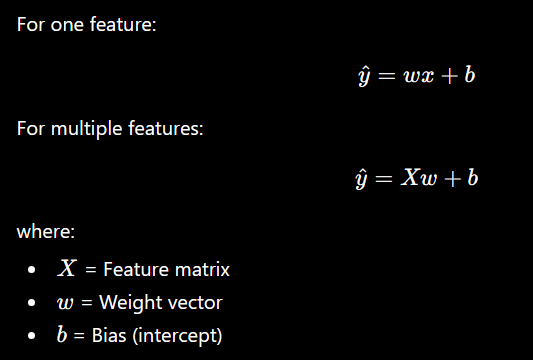

---

## 2. Ridge Loss Function

This is where Ridge differs from Linear Regression.

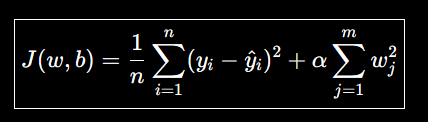

This is the objective that Ridge tries to minimize.

It has two parts:

```text
Total Loss

=

Prediction Error

+

Regularization Penalty
```

---

# Meaning of Every Symbol

| Symbol   | Meaning                      |
| -------- | ---------------------------- |
| (X)      | Feature matrix               |
| (y)      | Actual target values         |
| (\hat y) | Predicted values             |
| (w)      | Weight vector (coefficients) |
| (b)      | Bias (intercept)             |
| (n)      | Number of training samples   |
| (m)      | Number of features           |
| (\alpha) | Regularization strength      |
| (J)      | Total loss function          |

---

### Breaking Down the Formula

### Part 1: Prediction Error

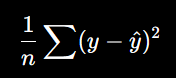

Measures how wrong the predictions are.

Smaller is better.

---

### Part 2: Penalty

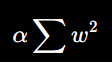

Measures how large the coefficients are.

Smaller is better.

---

Therefore,

Ridge wants

```text
Small Prediction Error

AND

Small Coefficients
```

simultaneously.

---

# Why This Formula Works

Suppose two models fit the training data almost equally well.

### Model A

```text
Weights

20

-15

18
```

Training Error

```text
10
```

---

### Model B

```text
Weights

4

-3

5
```

Training Error

```text
12
```

Linear Regression chooses

```text
Model A
```

because its training error is smaller.

---

Ridge computes

```
Total Loss

=

Training Error

+

Penalty
```

Penalty for Model A

```
20²+15²+18²

=

400+225+324

=

949
```

Penalty for Model B

```
4²+3²+5²

=

16+9+25

=

50
```

Although Model B has slightly higher training error, its total loss may be much smaller because the coefficients are far more reasonable.

This usually leads to better performance on unseen data.

---

# Why Are Coefficients Squared?

Suppose two weights

```text
5

-5
```

Without squaring,

```text
5 + (-5)

=

0
```

The penalty disappears.

That is incorrect.

---

With squaring,

```text
5² + (-5)²

=

25+25

=

50
```

Now both positive and negative coefficients are penalized equally.

---

Another advantage:

Large coefficients receive a much larger penalty.

Example

| Weight | Square |
| ------ | ------ |
| 1      | 1      |
| 2      | 4      |
| 5      | 25     |
| 10     | 100    |

Notice the penalty grows rapidly.

---

# Geometry Intuition

The geometry behind Ridge is one of the most important ideas in machine learning.

---

## Linear Regression

Linear Regression tries to find the point where the prediction error is minimum.

Imagine the loss surface:

```text
          Loss

           ▲

         ◯◯◯◯◯

       ◯       ◯

     ◯    ●      ◯

       ◯       ◯

         ◯◯◯◯◯
```

The center (●) is the minimum MSE.

---

## Ridge Regression

Ridge adds a constraint.

Instead of allowing coefficients to become arbitrarily large, it restricts them to remain inside a circle (in two dimensions).

```text
             MSE Contours

          ◯◯◯◯◯◯◯
       ◯             ◯
     ◯      ○○○      ◯
    ◯     ○     ○     ◯
    ◯    ○   ●   ○    ◯
    ◯     ○     ○     ◯
     ◯      ○○○      ◯
       ◯             ◯
          ◯◯◯◯◯◯◯
```

* **Large circles** = equal MSE (contours of the error surface).
* **Small inner circle** = allowed region imposed by the L2 constraint.
* **●** = best solution that satisfies both objectives.

The optimizer chooses the point where the lowest possible MSE contour first touches the constraint region.

This naturally leads to **smaller coefficients**.

---

# Optimization Intuition

Suppose the optimizer has two choices.

Option 1

```text
Prediction Error = 5

Penalty = 100

Total = 105
```

---

Option 2

```text
Prediction Error = 8

Penalty = 20

Total = 28
```

Even though Option 2 has a slightly higher prediction error, the overall loss is much smaller.

Therefore, Ridge prefers Option 2.

This is the fundamental trade-off behind regularization.

---

# Hyperparameter Effect

The only major hyperparameter is **α (alpha)**.

---

## α = 0

```text
No Regularization
```

Equivalent to ordinary Linear Regression.

---

## Small α

```text
Very Small Penalty
```

Coefficients shrink only slightly.

Predictions remain very similar to Linear Regression.

---

## Medium α

```text
Balanced Regularization
```

Usually provides the best generalization.

---

## Large α

```text
Strong Regularization
```

Weights become much smaller.

Training error increases slightly.

Testing error may decrease if the original model was overfitting.

---

## Extremely Large α

```text
Very Strong Penalty
```

Almost all coefficients become close to zero.

Predictions approach the mean of the target values.

This causes **underfitting**.

---

### Summary Table

| α Value    | Model Behavior    |
| ---------- | ----------------- |
| 0          | Linear Regression |
| Small      | Slight shrinkage  |
| Medium     | Good balance      |
| Large      | Strong shrinkage  |
| Very Large | Underfitting      |

---

# Time Complexity

The complexity depends on the optimization method.

### Closed-form Solution

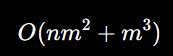

where:

* (n) = number of samples
* (m) = number of features

The (m^3) term comes from matrix inversion.

This is efficient for datasets with a moderate number of features but becomes expensive when (m) is very large.

---

### Gradient Descent

Each iteration processes all samples and features.

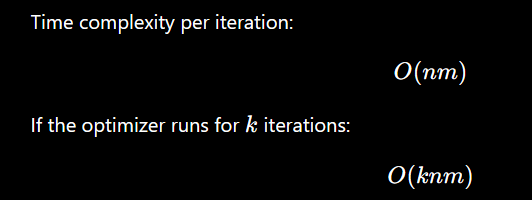

---

# Space Complexity

The model mainly stores:

* Feature matrix (X)
* Target vector (y)
* Weight vector (w)

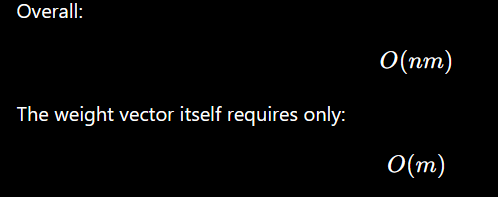

---

# Comparison with Linear Regression

| Property           | Linear Regression         | Ridge Regression                               |
| ------------------ | ------------------------- | ---------------------------------------------- |
| Prediction Formula | (Xw+b)                    | (Xw+b)                                         |
| Loss Function      | MSE                       | MSE + L2 Penalty                               |
| Objective          | Minimize prediction error | Minimize prediction error and coefficient size |
| Overfitting        | Higher risk               | Lower risk                                     |
| Coefficients       | Can become large          | Shrunk toward zero                             |
| Multicollinearity  | Poor handling             | Good handling                                  |

---

# Key Takeaways

* The **prediction equation** in Ridge Regression is **identical** to Linear Regression.
* The **only mathematical change** is the addition of the **L2 regularization term** to the loss function.
* Squaring the coefficients ensures that both positive and negative weights are penalized equally and that large weights receive a disproportionately larger penalty.
* The hyperparameter **α** controls the strength of regularization:

  * Small α → behaves like Linear Regression.
  * Large α → stronger shrinkage.
  * Extremely large α → underfitting.
* Geometrically, Ridge constrains the solution to remain within a bounded region, leading to smaller and more stable coefficients.

---